<a href="https://colab.research.google.com/github/slogan02/Final_Project/blob/main/Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Startup**

In [270]:
# Mount file into my drive
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [271]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [272]:
# Load Dataset
df = pd.read_csv('/content/drive/MyDrive/Student_Performance_Data.csv')
df.sample(n=5)

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
1678,2679,16,0,0,3,9.636745,24,0,0,0,0,0,0,0.632826,4
727,1728,17,1,0,3,16.062662,14,0,3,0,0,0,0,2.330783,3
982,1983,18,1,2,1,8.045894,17,0,3,0,1,0,0,1.722726,4
2360,3361,18,0,1,3,12.684862,20,0,2,0,0,0,0,1.347633,2
2007,3008,17,0,0,1,13.522836,23,1,4,1,0,0,0,1.964847,4


# **Data Exploration**

In [273]:
# Basic Statistics for Each Variable
print(df.shape)
print(df.info())
print(df.describe())

(2392, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2392 entries, 0 to 2391
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   StudentID          2392 non-null   int64  
 1   Age                2392 non-null   int64  
 2   Gender             2392 non-null   int64  
 3   Ethnicity          2392 non-null   int64  
 4   ParentalEducation  2392 non-null   int64  
 5   StudyTimeWeekly    2392 non-null   float64
 6   Absences           2392 non-null   int64  
 7   Tutoring           2392 non-null   int64  
 8   ParentalSupport    2392 non-null   int64  
 9   Extracurricular    2392 non-null   int64  
 10  Sports             2392 non-null   int64  
 11  Music              2392 non-null   int64  
 12  Volunteering       2392 non-null   int64  
 13  GPA                2392 non-null   float64
 14  GradeClass         2392 non-null   int64  
dtypes: float64(2), int64(13)
memory usage: 280.4 KB
None
        

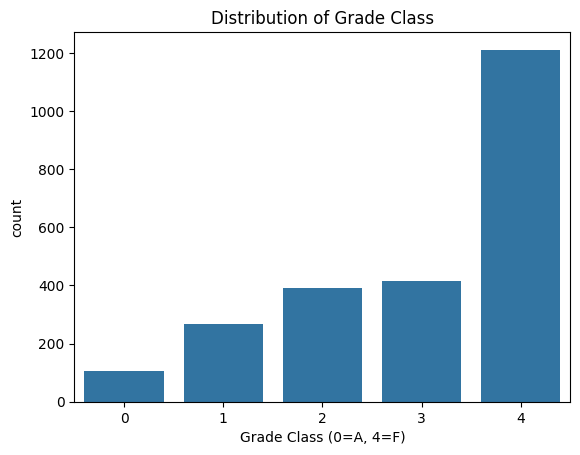

In [274]:
# Target Variable Distribution Plot
sns.countplot(x='GradeClass', data=df)
plt.title("Distribution of Grade Class")
plt.xlabel("Grade Class (0=A, 4=F)")
plt.show()

In [275]:
# Count the amount for each grade class
grade_counts = df['GradeClass'].value_counts().sort_index()

# Print values
print("Count of students per GradeClass (0=A, 4=F):\n")
print(grade_counts)

Count of students per GradeClass (0=A, 4=F):

GradeClass
0     107
1     269
2     391
3     414
4    1211
Name: count, dtype: int64


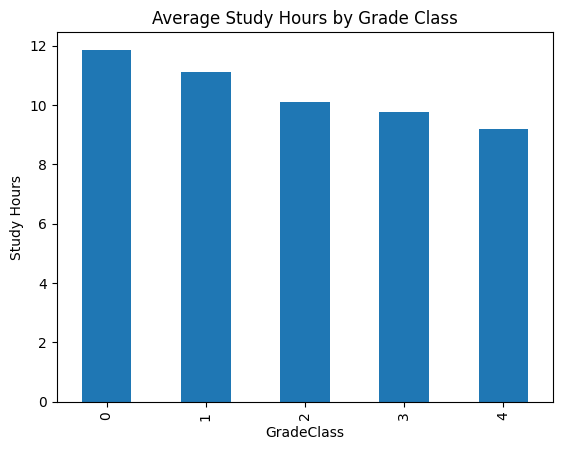

In [276]:
# Create average for each Grade Class by Study Time Weekly
df.groupby('GradeClass').mean()['StudyTimeWeekly'].plot(kind='bar')
plt.title("Average Study Hours by Grade Class")
plt.ylabel("Study Hours")
plt.show()

The visualization above shows that students that tend to receive higher grades typically spend more hours studying weekly then students that are in a lower grade class.

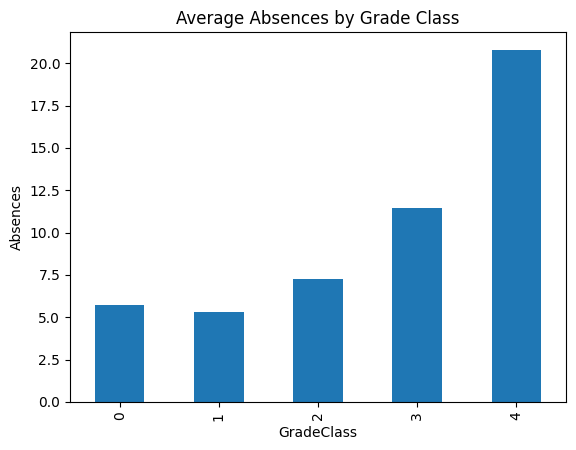

In [277]:
# Create average for each Grade Class by Absences
df.groupby('GradeClass').mean()['Absences'].plot(kind='bar')
plt.title("Average Absences by Grade Class")
plt.ylabel("Absences")
plt.show()

The visualization above shows that students that tend to receive higher grades typically have less absences then students that are in a lower grade class.

In [278]:
# Check for any Missing Values
missing_values = df.isnull().sum()

print("Missing Values by Variable:")
print(missing_values)

Missing Values by Variable:
StudentID            0
Age                  0
Gender               0
Ethnicity            0
ParentalEducation    0
StudyTimeWeekly      0
Absences             0
Tutoring             0
ParentalSupport      0
Extracurricular      0
Sports               0
Music                0
Volunteering         0
GPA                  0
GradeClass           0
dtype: int64


### **Data Visualizations**

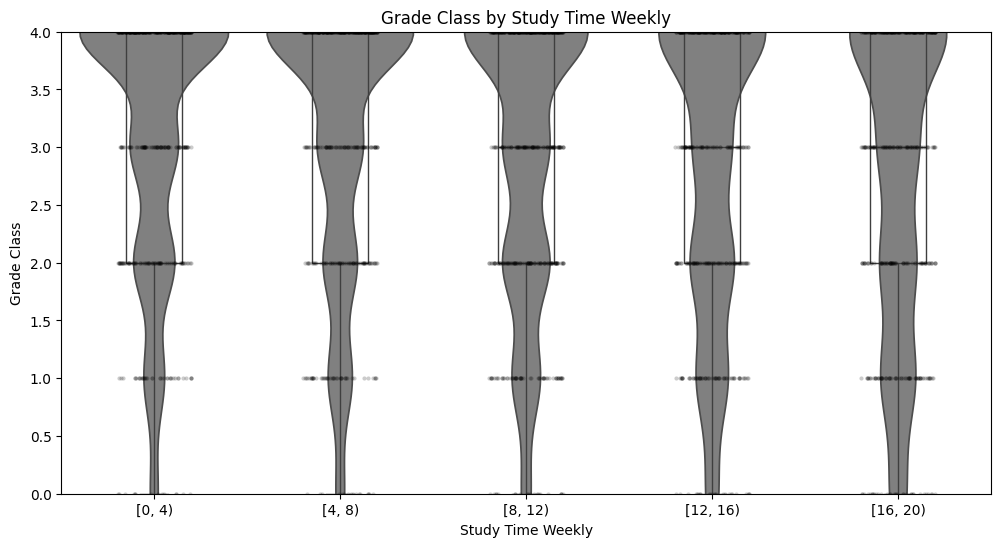

In [279]:
## Grade Class by Study Time Weekly
# Create figure and define bins for visualization
plt.figure(figsize=(12,6))
bin_edges = list(range(0, 21, 4))

# Convert data into categorical bins and into string format
df['StudyTimeBin'] = pd.cut(df['StudyTimeWeekly'], bins=bin_edges, include_lowest=True, right=False)
df['StudyTimeBinStr'] = df['StudyTimeBin'].astype(str)
# Order bins
df['StudyTimeBinStr'] = pd.Categorical(df['StudyTimeBinStr'], categories=[str(interval) for interval in df['StudyTimeBin'].cat.categories], ordered=True)
# Violin Plot
sns.violinplot(x='StudyTimeBinStr', y='GradeClass', data=df, inner=None, color='gray')
# Boxplot Overlay
sns.boxplot(x='StudyTimeBinStr', y='GradeClass', data=df, showcaps=True, boxprops={'facecolor':'None'}, width=0.3)
# Strip Plot
sns.stripplot(x='StudyTimeBinStr', y='GradeClass', data=df, color='black', alpha=0.2, jitter=0.2, size=3)

# Labeling
plt.xlabel('Study Time Weekly')
plt.ylabel('Grade Class')
plt.title('Grade Class by Study Time Weekly')
plt.ylim(0, 4)
plt.show()

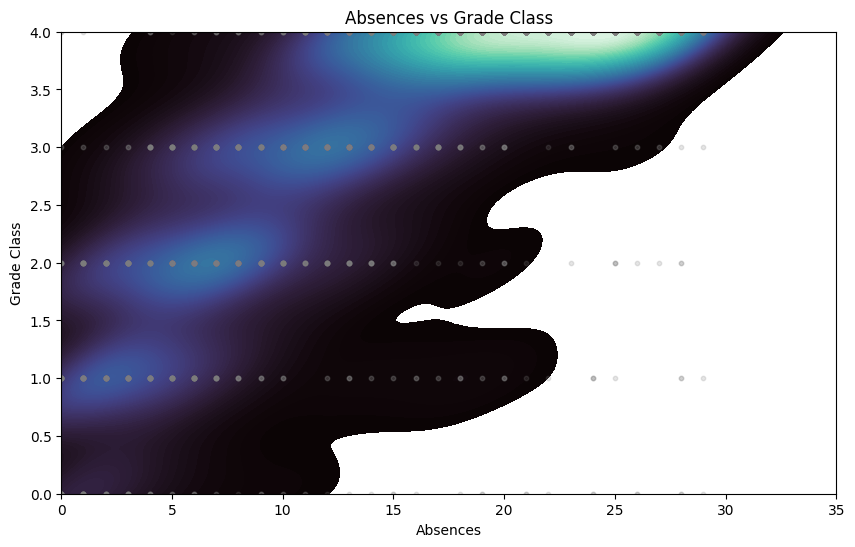

In [280]:
## Grade Class by Absences
# Create figure
plt.figure(figsize=(10,6))
#KDE Plot
sns.kdeplot( x=df['Absences'], y=df['GradeClass'], fill=True, thresh=0.03, levels=100, cmap="mako")

# Scatter Plot
plt.scatter(df['Absences'], df['GradeClass'], s=10, alpha=0.2, color='gray')

# Labeling
plt.xlabel('Absences')
plt.ylabel('Grade Class')
plt.title('Absences vs Grade Class')
plt.ylim(0, 4)
plt.xlim(0, 35)
plt.show()

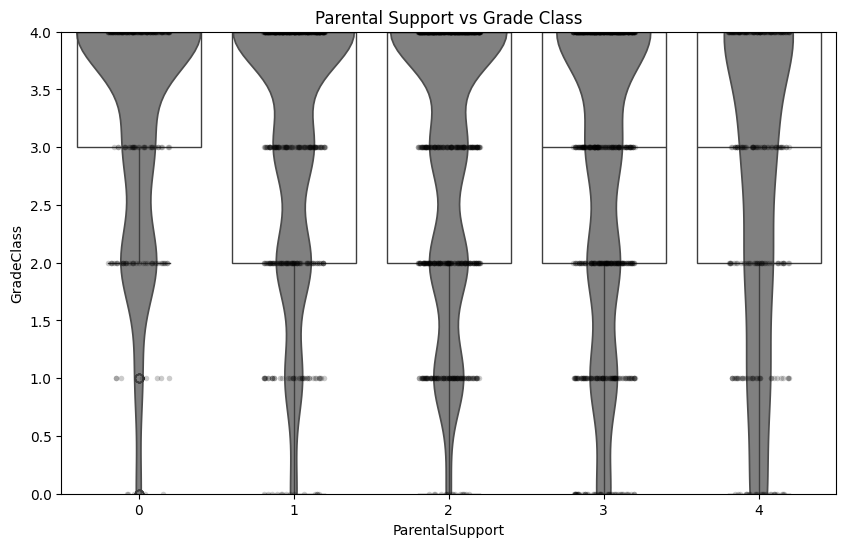

In [281]:
## Grade Class vs Parental Support (0-Low, 4-High)
# Create figure
plt.figure(figsize=(10,6))

# Violin Plot
sns.violinplot(x='ParentalSupport', y='GradeClass', data=df, inner=None, color="gray")
# Boxplot Overlay
sns.boxplot(x='ParentalSupport', y='GradeClass', data=df, boxprops={'facecolor':'None'})
# Strip Plot
sns.stripplot(x='ParentalSupport', y='GradeClass', data=df, jitter=0.2, size=4, alpha=0.2, color='black')

# Labeling
plt.ylim(0,4)
plt.title('Parental Support vs Grade Class')
plt.show()


The dataset contains no missing values (Thank God), meaning no removal process is needed during the preprocessesing stage. The target variable, GradeClass, has a slight imbalance. Some grade categories appear more frequently than others. Additionally, key relationships with the study time variable, absences, and parental support can be observed with the target variable. This analysis can indicate these variables may be important predictors in the model.



**Feature Engineering**

In [282]:
# Study efficiency
df['StudyEfficiency'] = df['StudyTimeWeekly'] / (df['Absences'] + 1)

# Combined support
df['TotalSupport'] = df['ParentalSupport'] + df['Tutoring']

# Activity engagement
df['ActivityScore'] = df['Sports'] + df['Music'] + df['Volunteering']

# Support by Activity
df['SupportPerActivity'] = df['TotalSupport'] / (df['Extracurricular'] + 1)

# Risk Score
df['RiskScore'] = df['Absences'] * (1 / (df['StudyTimeWeekly'] + 1))

1. **Study Effiency**
The formula is 'StudyEfficiency' = 'StudyTimeWeekly' / ('Absences' + 1)
This feature captures how effectively a student uses their study time relative to attendance. While study time and abscenses individually provide useful information, combining reveals the efficiency rating and whether a student is managing time well.
Both attendance and study time are important to success. A student who studies frequently and attends class will perform well, vice versa.

2. **Combined Support**
The formula is 'TotalSupport' = 'ParentalSupport' + 'Tutoring'
This feature combines two forms of academic support into a single variable. This captures the level of assistance a student receives. It provides a more complete picture.
Students who receive support both at home and tutoring are more likely to perform better academically. Combining these factors reflects the cumulative effect of academic support systems.

3. **Activity Score**
The formula is 'ActivityScore' = 'Sports' + 'Music' + 'Volunteering'
This feature measures overall student engagement in extracurricular activities, which may influence time management, discipline, and overall performance.
Participation in extracurricular activities is often associated with improved social skills, time management, and personal development, all of which can positively impact academic performance when balanced appropriately.

4. **Support by Activity**
The formula is 'SupportperActivity' = 'TotalSupport' / ('Extracurriculars' + 1) This feature measures how much academic or personal support a student receives relative to their level of extracurricular involvement. This captures the idea that support alone is not only what matters is how effectively that support translates into engagement. Reflects how support systems contribute to overall student development

5. **Risk Score**
The formula is 'RiskScore' = 'Absences' * (1/ ('StudyTimeWeekly' + 1))
This feature combines student absences and study time into a single metric that identifies academically at-risk students. High absences and low study hours are both strong indicators of poor performance, but when combined, they create a more powerful signal of pooe performance. This feature reflects real-world academic risk factors. Students who frequently miss class and do not invest time in studying are significantly more likely to struggle.


**Data Prepartion**

In [283]:
# Remove insignificant variables and target
X = df.drop(['GradeClass', 'StudentID', 'GPA'], axis=1)
# Target Variable
y = df['GradeClass']

In [284]:
# Categorical Columns
categorical_cols = X.select_dtypes(include=['object', 'category']).columns
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

In [285]:
# Initialize Scaler
scaler = StandardScaler()
# Fit scaler on data
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## **Random Forest**

In [286]:
## Random Forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
# Initialize Classifier
rf = RandomForestClassifier(max_depth=10, n_estimators=500, min_samples_split=2, random_state=42)

# Train Model
rf.fit(X_train, y_train)
# Generate Predictions
rf_preds = rf.predict(X_test)
# Print Model Performance
print("Random Forest Accuracy:", accuracy_score(y_test, rf_preds))
print(classification_report(y_test, rf_preds))

Random Forest Accuracy: 0.7118997912317327
              precision    recall  f1-score   support

           0       0.40      0.10      0.15        21
           1       0.54      0.56      0.55        54
           2       0.52      0.58      0.55        78
           3       0.50      0.57      0.53        83
           4       0.91      0.89      0.90       243

    accuracy                           0.71       479
   macro avg       0.57      0.54      0.54       479
weighted avg       0.71      0.71      0.71       479



In [287]:
# Parameter Grid
param_grid = {
    'n_estimators': [100, 500],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_rf = grid.best_estimator_
best_rf

RandomForestClassifier(max_depth=10, min_samples_split=5, n_estimators=500,
                       random_state=42)

### **Random Forest Confusion Matrix**

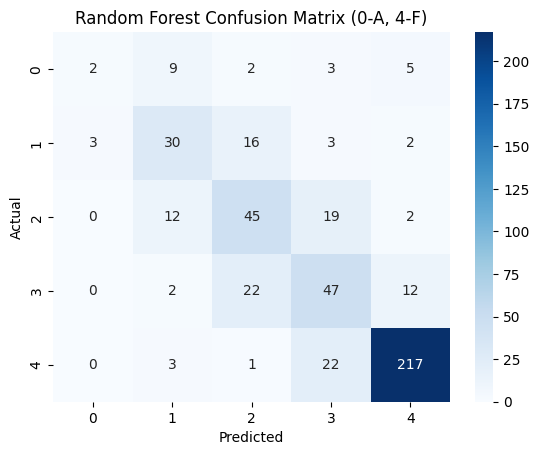

In [288]:
# Create Confusion Matrix
cm = confusion_matrix(y_test, rf_preds)
# Plot Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
# Labeling
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title("Random Forest Confusion Matrix (0-A, 4-F)")
plt.show()

### Random Forest Experimentation

To improve the Random Forest model, GridSearchCV was used to test different values for the number of trees, max depth, and minimum samples split. This helped find a better combination of settings compared to the default model and improved overall performance.

## **Neural Network**

In [289]:
## Neural Network
from sklearn.neural_network import MLPClassifier
# Initialize Classifier
nn = MLPClassifier(hidden_layer_sizes=(32, ), random_state=42)

# Train Model
nn.fit(X_train, y_train)
# Generate Predictions
nn_preds = nn.predict(X_test)
# Print Model Performance
print("Neural Network Accuracy:", accuracy_score(y_test, nn_preds))
print(classification_report(y_test, nn_preds))

Neural Network Accuracy: 0.7056367432150313
              precision    recall  f1-score   support

           0       0.25      0.14      0.18        21
           1       0.50      0.50      0.50        54
           2       0.49      0.51      0.50        78
           3       0.55      0.55      0.55        83
           4       0.90      0.91      0.90       243

    accuracy                           0.71       479
   macro avg       0.54      0.52      0.53       479
weighted avg       0.70      0.71      0.70       479



/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


### **Neural Network Confusion Matrix**

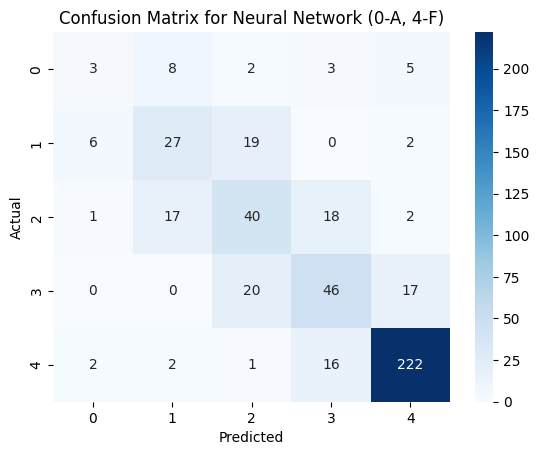

In [290]:
# Create Confusion Matrix
cm = confusion_matrix(y_test, nn_preds)
# Generate Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=True, yticklabels=True)
# Labeling
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Neural Network (0-A, 4-F)')
plt.show()

### Neural Network Experimentation

For the neural network, I experimented by changing the number of hidden layers. I also adjusted the max iterations to help the model train longer. The best results came from a simpler network, since larger ones tended to overfit and didn't improve accuracy much.

## Other Model Performance Visualizations

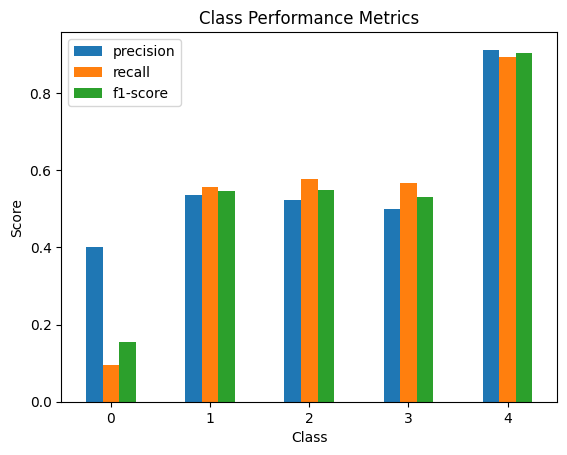

In [291]:
# Create a Performance Metric Visualization for Grade Class
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(y_test, rf_preds, output_dict=True)
report_df = pd.DataFrame(report).transpose()
class_df = report_df.iloc[:-3]
class_df[['precision', 'recall', 'f1-score']].plot(kind='bar')

plt.title("Class Performance Metrics")
plt.xlabel("Class")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

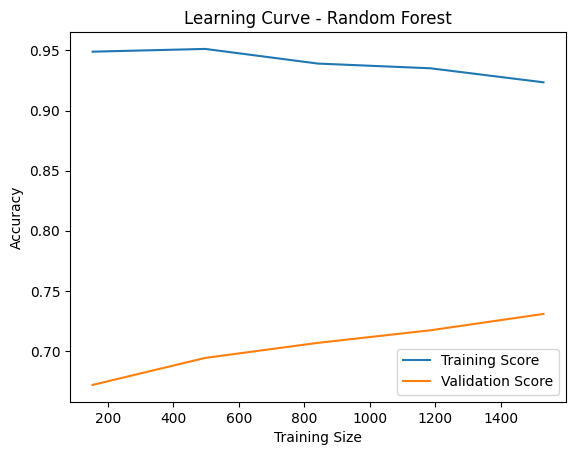

In [292]:
# Learning Curve for Random Forest
from sklearn.model_selection import learning_curve
import numpy as np

train_sizes, train_scores, val_scores = learning_curve(
    best_rf, X_train, y_train, cv=5, scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 5)
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.figure()
plt.plot(train_sizes, train_mean, label="Training Score")
plt.plot(train_sizes, val_mean, label="Validation Score")

plt.title("Learning Curve - Random Forest")
plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

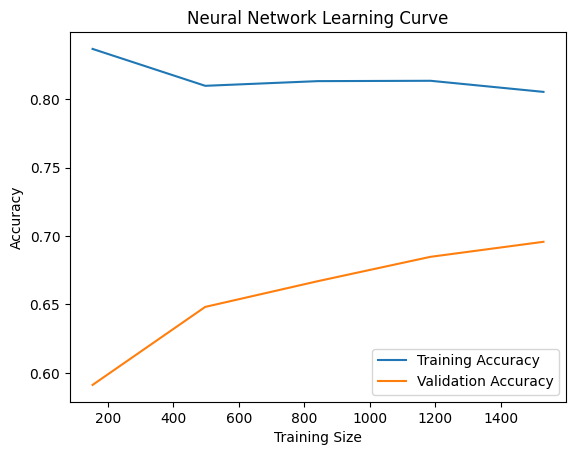

In [293]:
# Learning Curve for Neural Network
train_sizes, train_scores, val_scores = learning_curve(
    nn,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 5),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.figure()

plt.plot(train_sizes, train_mean, label="Training Accuracy")
plt.plot(train_sizes, val_mean, label="Validation Accuracy")

plt.title("Neural Network Learning Curve")
plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

### Feature Importance

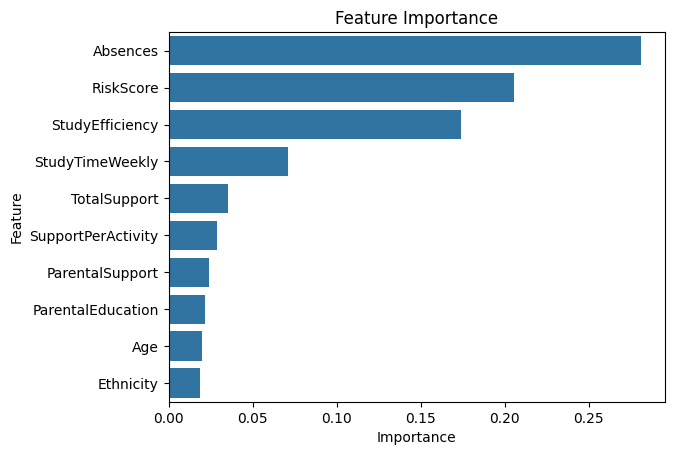

In [294]:
# Feature Importance
importances = best_rf.feature_importances_

features = X_encoded.columns

feat_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False).head(10)

plt.figure()
sns.barplot(x='Importance', y='Feature', data=feat_df)
plt.title("Feature Importance")
plt.show()

## **Compare Model Performance**

In [295]:
# Import scoring metrics and time
from sklearn.metrics import precision_score, recall_score, f1_score, mean_squared_error, mean_absolute_error
import time

# Record training time for Random Forest
start_rf = time.time()
rf.fit(X_train, y_train)
end_rf = time.time()
rf_time = end_rf - start_rf

# Record training time for Neural Network
start_nn = time.time()
nn.fit(X_train, y_train)
end_nn = time.time()
nn_time = end_nn - start_nn

# Create Dataframe to Compare Model Performance
results = pd.DataFrame({
    "Model": ["Random Forest", "Neural Network"],
    # Accuracy
    "Accuracy": [accuracy_score(y_test, rf_preds), accuracy_score(y_test, nn_preds)],
    # Precision
    "Precision": [precision_score(y_test, rf_preds, average='weighted'), precision_score(y_test, nn_preds, average='weighted')],
    # Recall
    "Recall": [recall_score(y_test, rf_preds, average='weighted'), recall_score(y_test, nn_preds, average='weighted')],
    # F1
    "F1 Score": [f1_score(y_test, rf_preds, average='weighted'), f1_score(y_test, nn_preds, average='weighted')],
    # RMSE
    "RMSE": [np.sqrt(mean_squared_error(y_test, rf_preds)), np.sqrt(mean_squared_error(y_test, nn_preds))],
    # MAE
    "MAE": [mean_absolute_error(y_test, rf_preds), mean_absolute_error(y_test, nn_preds)],
    # Training Time
    "Training Time": [rf_time, nn_time]
})

# Print Results
results


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


,Model,Accuracy,Precision,Recall,F1 Score,RMSE,MAE,Training Time
0,Random Forest,0.711900,0.712320,0.711900,0.707359,0.800574,0.373695,2.423443
1,Neural Network,0.705637,0.696916,0.705637,0.700538,0.817348,0.379958,1.099335


The Random Forest model performs better overall, achieving higher accuracy and more consistent precision, recall, and F1 scores. This is likely because Random Forest is better suited for structured data and can effectively capture relationships between features without extensive tuning. In contrast, the Neural Network model offers greater flexibility in modeling complex patterns. However, the training time for the Random Forest classifier is greater compared to the neural network.

In [296]:
comparison_df = pd.DataFrame({
    "Metric": [
        "Model Type",
        "Key Parameters",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "Training Time",
        "Strengths",
        "Limitations"
    ],
    "Random Forest": [
        "Tree-based",
        "max_depth=10, n_estimators=500",
        0.711900,
        0.696916,
        0.711900,
        0.700538,
        "2.423443",
        "Stable, interpretable, robust",
        "Limited nonlinear modeling"
    ],
    "Neural Network": [
        "Deep Learning",
        "layers=[32, ], max_iter=100",
        0.705637,
        0.725857,
        0.705637,
        0.728910,
        "1.099335",
        "Captures nonlinear patterns",
        "Less interpretable, needs tuning"
    ]
})

comparison_df

,Metric,Random Forest,Neural Network
0,Model Type,Tree-based,Deep Learning
1,Key Parameters,"max_depth=10, n_estimators=500","layers=[32, ], max_iter=100"
2,Accuracy,0.736952,0.734864
3,Precision,0.736659,0.725857
4,Recall,0.736952,0.734864
5,F1-score,0.730282,0.72891
6,Training Time,1.947,0.531
7,Strengths,"Stable, interpretable, robust",Captures nonlinear patterns
8,Limitations,Limited nonlinear modeling,"Less interpretable, needs tuning"


### Prediction Examples

In [297]:
# Prediction Examples
preds = best_rf.predict(X_test)
probs = best_rf.predict_proba(X_test)

# Build comparison data
results = pd.DataFrame(X_test, columns=X_encoded.columns)
results['True Label'] = y_test.values
results['Predicted Label'] = preds

# Add prediction confidence
results['Confidence'] = np.max(probs, axis=1)

# 10 random examples
sample_results = results.sample(n=10, random_state=42)
sample_results

# **Reflection**



Based on my initial results, additional feature engineering variables will focus on capturing more complex relationships between student behavior and performance. They will likely combine study time and parental support to better reflect how suppot systems influence study habits. Additionally, to create categories for absences to better capture nonlinear effects. Expanding beyond the initial three engineered features will help uncover deeper patterns that may improve model performance.

To improve the performance of the selected model, I plan to apply advanced tuning techniques. This will include optimizing parameters like the number of trees, maximum depth, and minimum samples per split to reduce overfitting and improve generalization. Also, I will explore feature selection methods to remove less important variables and improve efficiency. For the neural network, a potential improvement is adjusting the network architecture and adding regularization to address possible overfitting observed in the initial results.

One area where I would like help is on the significance of my engineered features and whether they meaningfully capture the relationships within the data. Additionally, guidance on whether additional preprocessing steps, such as further feature scaling or dimensionality reduction would significantly improve model performance would be valuable.

# Ethical Analysis & Responsible Deployment

One potential source of bias in this model comes from the features used to predict student performance. Variables such as study time, support systems, and extracurricular involvement may reflect underlying socioeconomic differences rather than purely academic ability. This introduces the risk of reinforcing existing inequalities if the model is used without careful consideration.

Incorrect predictions could negatively impact students. For example, a false negative may result in missed intervention opportunities. Conversely, a false positive could lead to unnecessary labeling or reduced expectations. These outcomes could disproportionately affect already vulnerable student populations.

To mitigate these risks, the model should be used as a decision-support tool rather than a fully automated system. Regular audits should be conducted to evaluate model performance across different groups, and fairness metrics should be monitored. Additionally, human oversight should remain a critical component of any deployment strategy.

# Business Recommendations & Deployment Considerations

The model provides actionable insights for identifying students at risk of poor academic performance. Schools can use these predictions to proactively allocate resources such as tutoring, mentoring, or counseling to students who need additional support. Feature importance analysis suggests that study habits and attendance play a significant role, indicating that interventions focused on improving these areas may yield the greatest impact.

For deployment, the model should be integrated into a decision-support system used by educators rather than fully automating decisions. Predictions should be reviewed by teachers or administrators before action is taken. A probability threshold can be used to flag high-risk students while minimizing false positives. The model should be retrained periodically, such as each semester, to maintain accuracy as new data becomes available.

It is important to acknowledge limitations. The model may not generalize well to different schools or populations without retraining. Additionally, it should not be used as the sole determinant of student ability, as it does not capture qualitative factors such as motivation, personal challenges, or learning styles.